# Frozen English/Slovene safety and utility test sets — `data.py` demo

This notebook walks through `data.py`, the script that assembles the **frozen, hashed EN/SL data protocol** for a bilingual refusal-suppression study (`google/gemma-3-12b-it` vs `cjvt/GaMS3-12B-Instruct`, each compared with a Heretic-abliterated version).

The script does three things:

1. **Checks raw provenance.** It confirms that every raw source listed in `data/provenance/sources.json` is present and has the declared row count.
2. **Verifies the frozen splits.** For each split family (`data/splits/<family>.jsonl`) it recomputes a SHA256 over the canonically sorted JSONL lines and compares it with `data/split_manifest.json`. If any frozen split was edited after freezing, the script stops.
3. **Assembles the output.** It validates the row schema (`input`/`output`/`metadata_*` only) and groups the 17 families into 10 output blocks. The result is `full_data_out.json`: 48,696 rows with a protocol hash that starts `dc33bde4…`.

| Block | Contents |
|---|---|
| `S1_heretic` | Heretic default harmful/harmless direction data, EN+SL |
| `S2_semantic` | Semantic-Harmful/Harmless (DEV only, overlaps S1) |
| `S3_screen_dev_*` | JBB, Dolly, FLORES dev, MC screening/dev sets |
| `S4_strongreject_pairs` | StrongREJECT prompts and their gpt-4.1 benign twins, EN+SL |
| `S5_refuseu` / `S5X_*` | Official RefusEU EN/SL eval rows and constructed cross-translations |
| `S6_xstest` | XSTest (over-refusal), EN+SL |
| `S7_*` | Slovenian LLM Eval + English counterparts, FLORES devtest |

**Demo data.** The full splits total about 56 MB, so this demo uses `mini_demo_data.json`. It holds **68 rows: 4 from every one of the 17 families**. Whole semantic-ID groups are kept together, so each EN row travels with its SL counterpart. The file also carries the manifest, the source list and the raw-source row counts. The demo manifest records the SHA256 of the *demo* lines under the key the script reads. The original full-split hashes are kept alongside for reference.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# data.py itself uses only the standard library. pandas/matplotlib are needed only for the summary/visualisation cells.
# They are pre-installed on Colab, so install them locally only, at Colab's exact versions.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- original import block of data.py ---
from __future__ import annotations

import hashlib
import json
import sys
from collections import Counter
from pathlib import Path

# --- extra imports for the notebook's summary / visualisation cells ---
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-beaa2a-what-english-tuned-abliteration-misses/main/round-1/dataset-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("families:", len(data["splits"]), "| demo rows:", sum(len(v) for v in data["splits"].values()))

Demo slice of the frozen EN/SL S1-S7 split files (whole semantic-ID groups, seed 0). `splits` holds exact JSONL lines; `split_manifest` is the original manifest with per-family demo SHA256 values; `sources` + `raw_row_counts` replace the raw temp/datasets/ files.
families: 17 | demo rows: 68


## Configuration

`data.py` has no numeric knobs such as iterations, sample sizes or seeds. It deterministically replays a frozen protocol, so its "parameters" are the block → family grouping and the set of forbidden keys. Both are copied verbatim below.

* `OUTPUT_FILE`: the original writes `full_data_out.json`. The demo writes `demo_data_out.json` so the demo output is never mistaken for the real corpus.
* `N_SHOW`: how many example rows the summary cell prints.
* **Scale:** the whole demo runs in about a second. For the full run, use `uv run data.py` in the artifact workspace, which reads all 48,696 rows from `data/splits/*.jsonl` and the raw files in `temp/datasets/`.

In [5]:
ROOT = Path(".")          # original: Path(__file__).resolve().parent (the artifact workspace)
OUTPUT_FILE = "demo_data_out.json"   # original: "full_data_out.json"
N_SHOW = 6                # rows printed in the summary cell

BLOCKS = {  # output block -> source families (data/splits/<family>.jsonl)
    "S1_heretic": ["S1_heretic"],
    "S2_semantic": ["S2_semantic"],
    "S3_screen_dev_prompts": ["S3_jbb", "S3_dolly"],
    "S3_screen_dev_utility": ["S3_flores_dev", "S3_mc"],
    "S4_strongreject_pairs": ["S4_strongreject_pairs"],
    "S5_refuseu": ["S5_refuseu"],
    "S5X_refuseu_crosstrans": ["S5X_refuseu_crosstrans"],
    "S6_xstest": ["S6_xstest"],
    "S7_slovenian_llm_eval": ["S7_arc_challenge", "S7_boolq", "S7_hellaswag", "S7_openbookqa", "S7_piqa", "S7_winogrande"],
    "S7_flores_devtest": ["S7_flores_devtest"],
}
FORBIDDEN = {"split", "dataset", "context"}

## Helper: logging

The original defines a one-line `log` helper that prints with an immediate flush.

In [6]:
def log(msg: str) -> None:
    print(msg, flush=True)

## Step 1: Check raw provenance

`check_raw_provenance()` goes through every source in `sources.json`, a list of HuggingFace repo, config, split, pinned revision, `n_rows` and SHA256. For each source it checks that the raw dump exists and has the declared number of rows. Sources stored as `{"pairs": [...]}` count their pairs.

**Demo change:** the raw dumps in `temp/datasets/` total about 50 MB and are not shipped. The builder script counted their rows with exactly this rule and stored the counts in `data["raw_row_counts"]`. The function now reads those counts instead of opening the files. The comparison logic is unchanged.

In [7]:
def check_raw_provenance() -> dict:
    """Re-hash every raw file in temp/datasets/ that sources.json lists (HF sources are hashed as the JSON dump we wrote)."""
    srcs = data["sources"]  # original: json.loads((ROOT / "data" / "provenance" / "sources.json").read_text())
    res = {"checked": 0, "missing": [], "rows_mismatch": []}
    for s in srcs:
        # original: f = ROOT / "temp" / "datasets" / f"full_{s['name']}.json"; if not f.exists(): ...
        if s["name"] not in data["raw_row_counts"]:
            res["missing"].append(s["name"]); continue
        # original: rows = json.loads(f.read_text())
        #           n = len(rows["pairs"]) if isinstance(rows, dict) and "pairs" in rows else len(rows)
        n = data["raw_row_counts"][s["name"]]
        if s.get("n_rows") is not None and n != s["n_rows"]:
            res["rows_mismatch"].append((s["name"], n, s["n_rows"]))
        res["checked"] += 1
    return res

## Step 2: Run the provenance gate (start of `main()`)

This is the first part of the original `main()`. If any source is missing or its row count differs, the script refuses to continue.

In [8]:
prov = check_raw_provenance()
log(f"raw provenance: {prov['checked']} source files present; missing={prov['missing']}; row mismatches={prov['rows_mismatch']}")
if prov["missing"] or prov["rows_mismatch"]:
    sys.exit("raw sources in temp/datasets/ do not match data/provenance/sources.json")

raw provenance: 34 source files present; missing=[]; row mismatches=[]


## Step 3: Verify the frozen splits and assemble the blocks

This is the core loop of `main()`. For each block and each of its families, it:

1. Reads the family's JSONL lines. In the demo they come from `data["splits"][fam]`, the exact line strings from the frozen files.
2. Computes `sha256("\n".join(sorted(lines)))`. Sorting makes the hash independent of row order, so it changes only if some row's content changes. If the hash differs from the manifest value, the script stops (`sys.exit`).
3. Checks the schema of every row: `input` is a non-empty string, `output` is a non-empty string, and every other key starts with `metadata_` (none of `split`/`dataset`/`context` are allowed).
4. Tags each row with its family in `metadata_subset` and appends it to the block.

The demo manifest holds the SHA256 of the demo subset under `sha256_canonical_sorted_jsonl`, so this check really runs on the 68 demo rows.

In [9]:
manifest = data["split_manifest"]  # original: json.loads((ROOT / "data" / "split_manifest.json").read_text())
out_blocks = []
totals = Counter()
for block, fams in BLOCKS.items():
    ex = []
    for fam in fams:
        # original: f = ROOT / "data" / "splits" / f"{fam}.jsonl"; lines = f.read_text().splitlines()
        lines = data["splits"][fam]
        body = "\n".join(lines)
        sha = hashlib.sha256("\n".join(sorted(lines)).encode()).hexdigest()
        want = manifest["splits"][fam]["sha256_canonical_sorted_jsonl"]
        if sha != want:
            sys.exit(f"{fam}: split sha {sha[:12]} != manifest {want[:12]} - frozen split was modified")
        for l in lines:
            r = json.loads(l)
            assert isinstance(r["input"], str) and r["input"].strip(), (fam, r.get("metadata_semantic_id"))
            assert isinstance(r["output"], str) and r["output"] != "", (fam, r.get("metadata_semantic_id"))
            bad = [k for k in r if k not in ("input", "output") and not k.startswith("metadata_")] + [k for k in r if k in FORBIDDEN]
            assert not bad, (fam, bad)
            r["metadata_subset"] = fam
            ex.append(r)
        del body
    out_blocks.append({"dataset": block, "examples": ex})
    totals[block] = len(ex)
    log(f"{block:<26} {len(ex):>6} examples  langs={dict(Counter(e['metadata_lang'] for e in ex))}")

S1_heretic                      4 examples  langs={'en': 2, 'sl': 2}


S2_semantic                     4 examples  langs={'en': 2, 'sl': 2}


S3_screen_dev_prompts           8 examples  langs={'en': 4, 'sl': 4}


S3_screen_dev_utility           8 examples  langs={'en': 4, 'sl': 4}


S4_strongreject_pairs           4 examples  langs={'en': 2, 'sl': 2}


S5_refuseu                      4 examples  langs={'en': 1, 'sl': 3}


S5X_refuseu_crosstrans          4 examples  langs={'sl': 2, 'en': 2}


S6_xstest                       4 examples  langs={'en': 2, 'sl': 2}


S7_slovenian_llm_eval          24 examples  langs={'en': 12, 'sl': 12}


S7_flores_devtest               4 examples  langs={'en': 2, 'sl': 2}


## Step 4: Write the metadata header and the output file

This is the end of `main()`. It builds the corpus-level metadata (title, protocol hash, freeze timestamp, the deterministic A/B *half* formula, per-block counts and caveat notes) and writes `{"metadata": ..., "datasets": [...]}`. The notes record the main data-protocol cautions:

* S2 overlaps S1.
* RefusEU EN/SL rows that share an ID are **not** translations.
* S5X rows are constructed, not official.
* All QC is automated; native review is still pending.

In [10]:
meta = {"title": "Frozen EN/SL data protocol (S1-S7) for the GaMS3-12B-Instruct vs gemma-3-12b-it bilingual abliteration study",
        "protocol_hash": manifest["protocol_hash"], "frozen_utc": manifest["frozen_utc"],
        "half_formula": manifest["half_formula"], "n_examples_total": sum(totals.values()),
        "blocks": {b: {"families": f, "n": totals[b]} for b, f in BLOCKS.items()},
        "notes": ["S2 overlaps S1 by construction (DEV only)", "RefusEU EN/SL rows sharing a row_id are NOT translations; see "
                  "metadata_correspondence_grade", "S5X rows are constructed cross-translations, never official RefusEU",
                  "all QC numbers are automated; native review PENDING"]}
(ROOT / OUTPUT_FILE).write_text(json.dumps({"metadata": meta, "datasets": out_blocks}, ensure_ascii=False))
log(f"wrote {OUTPUT_FILE}: {sum(totals.values())} examples in {len(out_blocks)} dataset blocks "
    f"({(ROOT / OUTPUT_FILE).stat().st_size / 1e6:.1f} MB)")

wrote demo_data_out.json: 68 examples in 10 dataset blocks (0.1 MB)


## Results and visualisation

The cells below summarise:

* the assembled demo output (rows per block, language and role, with a few EN/SL example pairs);
* the **full** frozen corpus composition, taken from the manifest's per-family counts;
* the automated translation-QC metrics carried on the translated SL rows;
* a short integrity check showing that editing a single character of a frozen row breaks its split hash.

In [11]:
rows = [dict(block=b["dataset"], **e) for b in out_blocks for e in b["examples"]]
df = pd.DataFrame(rows)
print("Demo output: rows per block x language")
print(pd.crosstab(df["block"], df["metadata_lang"], margins=True).to_string())
print()
print("Demo output: rows per block x role")
print(pd.crosstab(df["block"], df["metadata_role"]).to_string())

print("\nExample rows (EN/SL versions of the same semantic item stay together):")
show = df[df["metadata_subset"].isin(["S1_heretic", "S4_strongreject_pairs", "S6_xstest"])].head(N_SHOW)
for _, r in show.iterrows():
    print(f"[{r['metadata_subset']} | {r['metadata_lang']} | {r['metadata_role']} | sid={r['metadata_semantic_id']}] output={r['output']!r}")
    print("   ", r["input"][:160].replace("\n", " "))

# Full-corpus composition from the (original) manifest counts
full = pd.DataFrame([{"family": fam, "n_rows": v["full_split_n_rows"], **{f"n_{k}": n for k, n in v["by_lang"].items()},
                      "full_sha256": v["full_split_sha256_canonical_sorted_jsonl"][:12]}
                     for fam, v in manifest["splits"].items()]).fillna(0)
print(f"\nFull frozen corpus (protocol_hash {manifest['protocol_hash'][:12]}...): {int(full['n_rows'].sum())} rows")
print(full.to_string(index=False))

Demo output: rows per block x language
metadata_lang           en  sl  All
block                              
S1_heretic               2   2    4
S2_semantic              2   2    4
S3_screen_dev_prompts    4   4    8
S3_screen_dev_utility    4   4    8
S4_strongreject_pairs    2   2    4
S5X_refuseu_crosstrans   2   2    4
S5_refuseu               1   3    4
S6_xstest                2   2    4
S7_flores_devtest        2   2    4
S7_slovenian_llm_eval   12  12   24
All                     33  35   68

Demo output: rows per block x role
metadata_role           harmful  harmless  mc  parallel  safe  unsafe
block                                                                
S1_heretic                    2         2   0         0     0       0
S2_semantic                   2         2   0         0     0       0
S3_screen_dev_prompts         2         6   0         0     0       0
S3_screen_dev_utility         0         0   4         4     0       0
S4_strongreject_pairs         2      

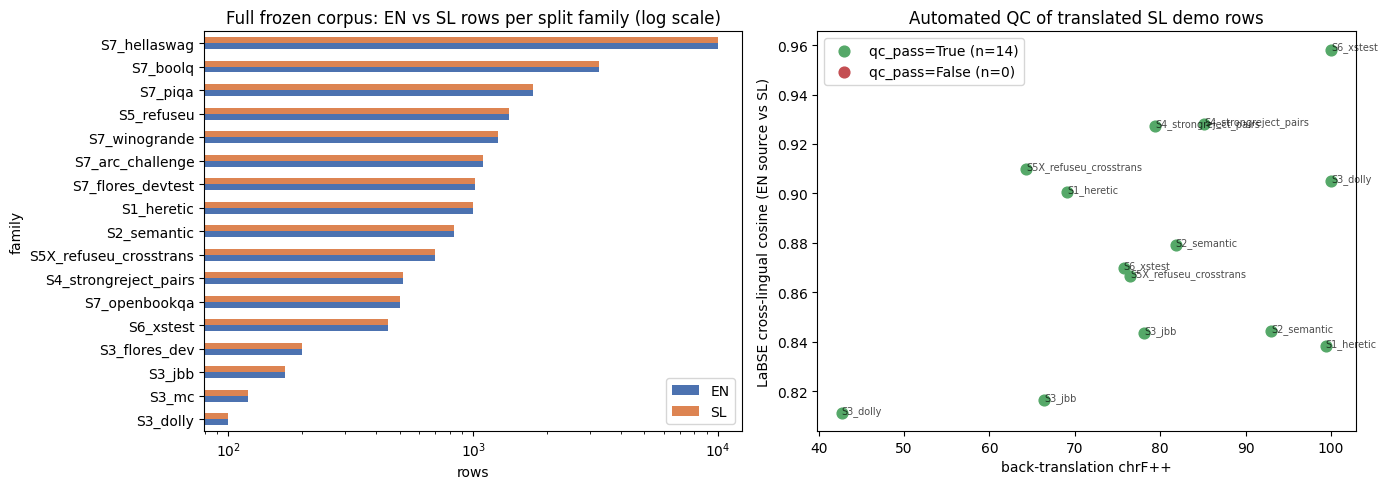

       metadata_subset                           metadata_translation_method  metadata_bt_chrf  metadata_labse_xl  metadata_len_ratio metadata_translation_unstable metadata_qc_pass
            S1_heretic                     pod_file(google/gemini-2.5-flash)             69.12             0.9004               0.911                         False             True
            S1_heretic pod_file(facebook/nllb-200-distilled-1.3B (fallback))             99.38             0.8383               1.026                         False             True
           S2_semantic                     pod_file(google/gemini-2.5-flash)             92.97             0.8444               0.938                         False             True
           S2_semantic                              gemini25flash_screenspec             81.81             0.8790               1.053                         False             True
                S3_jbb                     pod_file(google/gemini-2.5-flash)             66.37 

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) full corpus rows per family, EN and SL side by side (log scale: HellaSwag dominates)
f2 = full.set_index("family")[["n_en", "n_sl"]].sort_values("n_en")
f2.plot.barh(stacked=False, ax=axes[0], color=["#4C72B0", "#DD8452"], logx=True)
axes[0].set_title("Full frozen corpus: EN vs SL rows per split family (log scale)")
axes[0].set_xlabel("rows"); axes[0].legend(["EN", "SL"])

# (b) automated translation QC on translated SL demo rows
qc = df[(df["metadata_lang"] == "sl") & df.get("metadata_bt_chrf").notna()] if "metadata_bt_chrf" in df else df.iloc[0:0]
for ok, c in [(True, "#55A868"), (False, "#C44E52")]:
    s = qc[qc["metadata_qc_pass"] == ok]
    axes[1].scatter(s["metadata_bt_chrf"], s["metadata_labse_xl"], c=c, s=60, label=f"qc_pass={ok} (n={len(s)})")
for _, r in qc.iterrows():
    axes[1].annotate(r["metadata_subset"].replace("S7_", ""), (r["metadata_bt_chrf"], r["metadata_labse_xl"]), fontsize=7, alpha=.7)
axes[1].set_xlabel("back-translation chrF++"); axes[1].set_ylabel("LaBSE cross-lingual cosine (EN source vs SL)")
axes[1].set_title("Automated QC of translated SL demo rows"); axes[1].legend()
plt.tight_layout(); plt.show()

if len(qc):
    print(qc[["metadata_subset", "metadata_translation_method", "metadata_bt_chrf", "metadata_labse_xl",
              "metadata_len_ratio", "metadata_translation_unstable", "metadata_qc_pass"]].to_string(index=False))

In [13]:
# Integrity check: flip one character in one frozen row and recompute the canonical split hash, as data.py does
fam = "S5_refuseu"
lines = list(data["splits"][fam])
orig_sha = hashlib.sha256("\n".join(sorted(lines)).encode()).hexdigest()
tampered = lines.copy(); tampered[0] = tampered[0].replace("a", "A", 1)
tamp_sha = hashlib.sha256("\n".join(sorted(tampered)).encode()).hexdigest()
print(f"{fam}: manifest {manifest['splits'][fam]['sha256_canonical_sorted_jsonl'][:12]} | recomputed {orig_sha[:12]} | "
      f"after 1-char edit {tamp_sha[:12]} -> data.py would {'STOP' if tamp_sha != manifest['splits'][fam]['sha256_canonical_sorted_jsonl'] else 'continue'}")
# Row order does not matter: the hash is over sorted lines
print("shuffled order gives same hash:", hashlib.sha256("\n".join(sorted(lines[::-1])).encode()).hexdigest() == orig_sha)

S5_refuseu: manifest 0ad72f901b9f | recomputed 0ad72f901b9f | after 1-char edit 45d660cdb3fe -> data.py would STOP
shuffled order gives same hash: True
